In [37]:
import jax.numpy as jnp
import jax 
import matplotlib.pyplot as plt
import diffrax

from algorithms.nuts import nuts
from utilities.helpers import effective_sample_size,autocorr_new

#jax.config.update('jax_platform_name', 'cpu')

print(jax.devices())



[CudaDevice(id=0)]


In [38]:
def s(k, K):
    """A non-dimension coordinate from -1..+1 corresponding to k=0..K"""
    return 2 * (0.5 + k) / K - 1

In [39]:
K = 5  # Number of globa-scale variables X
J = 5  # Number of local-scale Y variables per single global-scale X variable
nt = 5  # Number of time steps
si = 0.005  # Sampling time interval
dt = 0.005  # Time step
F = 10.0  # Focring
h = jnp.log(8/10)  # Coupling coefficient
b = jnp.log(1/10.0)  # ratio of amplitudes
c = jnp.log(1/10.0)  # time-scale ratio
k = jnp.arange(K)  # For coordinate in plots
j = jnp.arange(J * K)  # For coordinate in plots

# Initial conditions
X_init = s(k, K) * (s(k, K) - 1) * (s(k, K) + 1)
Y_init = 0 * s(j, J * K) * (s(j, J * K) - 1) * (s(j, J * K) + 1)

In [40]:
def L96_2t_xdot_ydot(t, state, par):
    X,Y = state
    F, h, b, c = par
    h = 1/jnp.exp(h)
    b = 1/jnp.exp(b)
    c = 1/jnp.exp(c)
    """
    Calculate the time rate of change for the X and Y variables for the Lorenz '96, two time-scale
    model, equations 2 and 3:
        d/dt X[k] =     -X[k-1] ( X[k-2] - X[k+1] )   - X[k] + F - h.c/b sum_j Y[j,k]
        d/dt Y[j] = -b c Y[j+1] ( Y[j+2] - Y[j-1] ) - c Y[j]     + h.c/b X[k]

    Args:
        X : Values of X variables at the current time step
        Y : Values of Y variables at the current time step
        F : Forcing term
        h : coupling coefficient
        b : ratio of amplitudes
        c : time-scale ratio
    Returns:
        dXdt, dYdt, C : Arrays of X and Y time tendencies, and the coupling term -hc/b*sum(Y,j)
    """

    JK, K = len(Y), len(X)
    J = JK // K
    # assert JK == J * K, "X and Y have incompatible shapes"
    Xdot = jnp.zeros(K)
    hcb = (h * c) / b

    Ysummed = Y.reshape((K, J)).sum(axis=-1)

    Xdot = jnp.roll(X, 1) * (jnp.roll(X, -1) - jnp.roll(X, 2)) - X + F - hcb * Ysummed
    Ydot = (
        -c * b * jnp.roll(Y, -1) * (jnp.roll(Y, -2) - jnp.roll(Y, 1))
        - c * Y
        + hcb * jnp.repeat(X, J)
    )

    return (Xdot, Ydot)

In [41]:
def model(ts, y0, par):
    terms = diffrax.ODETerm(L96_2t_xdot_ydot)
    solution = diffrax.diffeqsolve(
        terms,
        diffrax.Dopri8(),
        t0=ts[0],
        t1=ts[-1],
        dt0=0.005,
        y0=y0,
        args=par,
        saveat=diffrax.SaveAt(ts=ts),
        max_steps = 100_000,
    )
    return solution.ys


In [42]:
t = jnp.arange(0, nt + dt, dt)
y0 = (X_init, Y_init)

par = (F, h, b, c)

X,Y = model(t, y0, par)


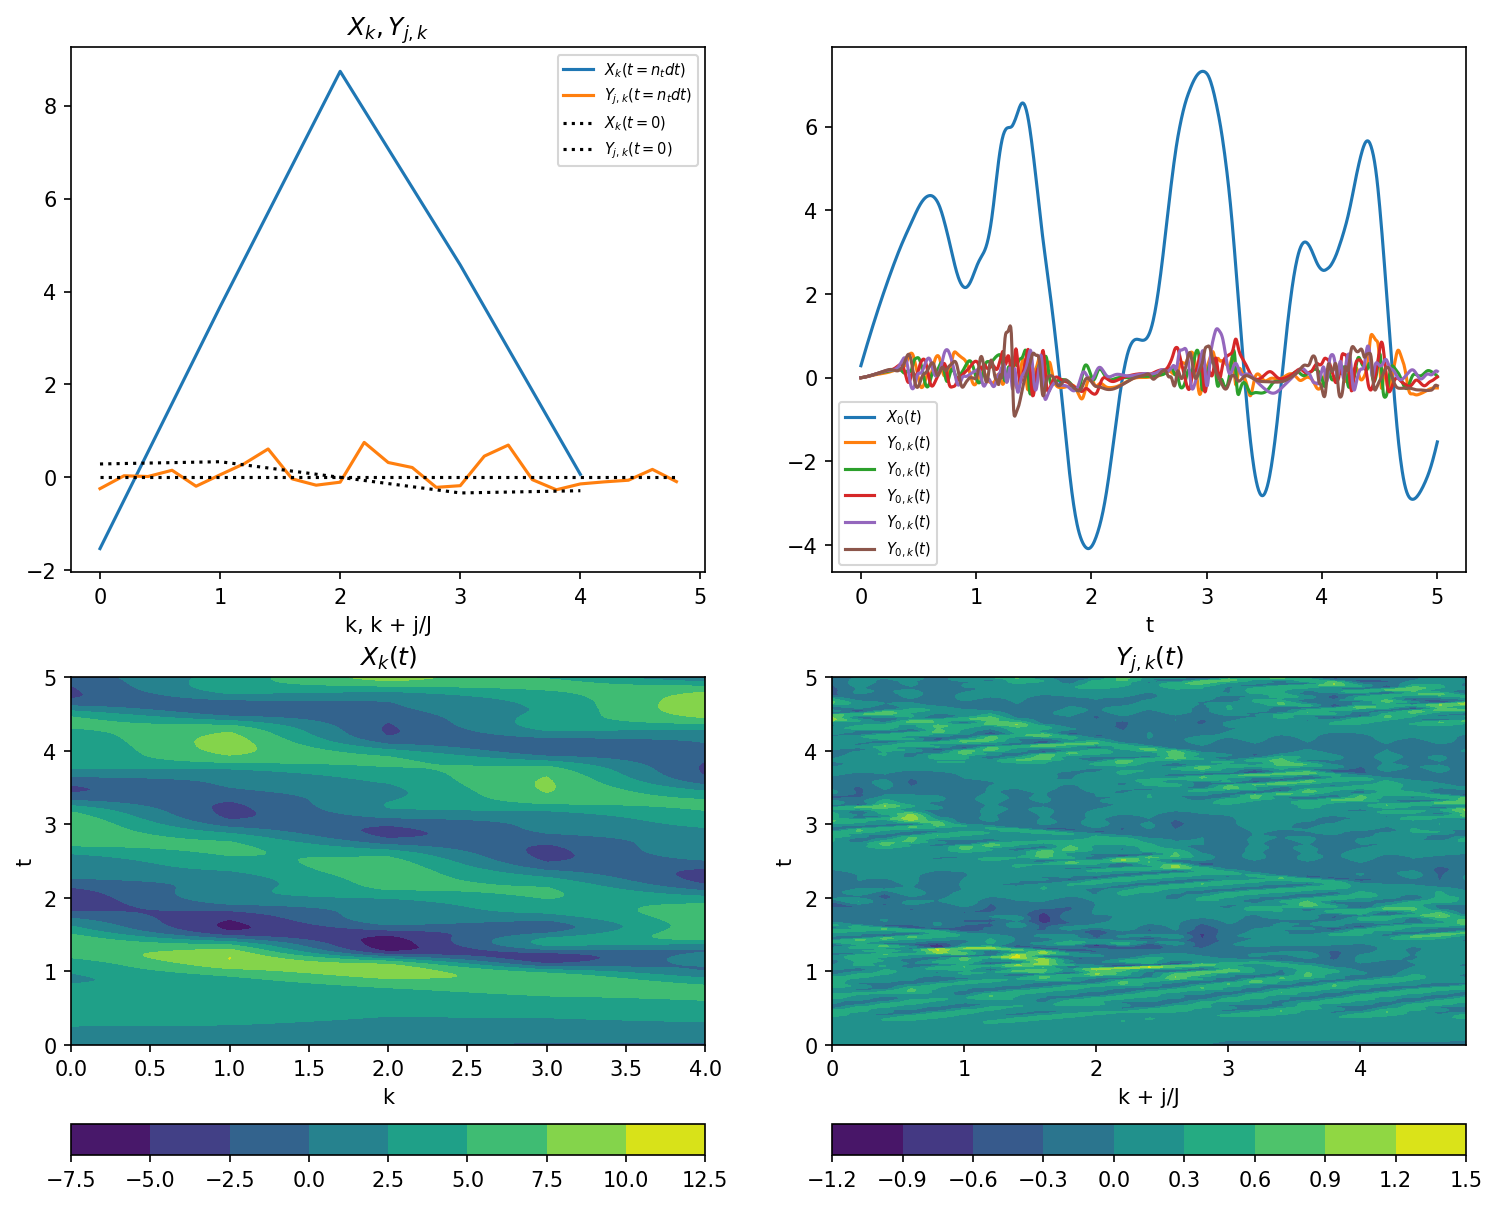

In [43]:
plt.figure(figsize=(12, 10), dpi=150)
plt.subplot(221)

# Snapshot of X[k]
plt.plot(k, X[-1], label="$X_k(t=n_t dt)$")
plt.plot(j / J, Y[-1], label="$Y_{j,k}(t=n_t dt)$")
plt.plot(k, X_init, "k:", label="$X_k(t=0)$")
plt.plot(j / J, Y_init, "k:", label="$Y_{j,k}(t=0)$")
plt.legend(fontsize=7)
plt.xlabel("k, k + j/J")
plt.title("$X_k, Y_{j,k}$")
plt.subplot(222)

# Sample time-series X[0](t), Y[0](t)
plt.plot(t, X[:, 0], label="$X_0(t)$")
plt.plot(t, Y.reshape((len(t), K, J))[:, 0, :], label="$Y_{0,k}(t)$")
plt.legend(fontsize=7)
plt.xlabel("t")
plt.subplot(223)

# Full model history of X
plt.contourf(k, t, X)
plt.colorbar(orientation="horizontal")
plt.xlabel("k")
plt.ylabel("t")
plt.title("$X_k(t)$")
plt.subplot(224)

# Full model history of Y
plt.contourf(j / J, t, Y)
plt.colorbar(orientation="horizontal")
plt.xlabel("k + j/J")
plt.ylabel("t")
plt.title("$Y_{j,k}(t)$");

In [44]:
def data_map(par, _):
    h,b,c = par
    full_state,_ = model(t, (X_init,Y_init), (F,h,b,c))

    return full_state.ravel()

In [ ]:
from algorithms.EKI import EnsembleKalmanInversion

observations =  X.ravel()

cov = jnp.eye(K * len(t))
rng_key = jax.random.key(0)
rng_key, noise_key = jax.random.split(rng_key)

dim_output = 3

num_ensemble_members = 100

rng_key, init_ensemble_key, init_key = jax.random.split(rng_key, 3)

initial_ensemble = jnp.log(jnp.array([1/5,1/5,1/5])) + jax.random.normal(
    init_ensemble_key, (num_ensemble_members, dim_output)
)

(final_ensemble,_), _ = EnsembleKalmanInversion(
    initial_ensemble,
    observations,
    cov,
    lambda x, y: jax.vmap(data_map, in_axes=(0, 0))(x, y),
    0.01,
    init_key,
)

print(jnp.mean(jnp.exp(final_ensemble),axis = 0))